# TechMind — Corpus Preparation Pipeline

Construye el corpus de entrenamiento y evaluación para TechMind (Hackathon ONE, Alura + Oracle · G9 LatAm).

**Entra:** StackSample (Kaggle), Dev.to (API), Stack Exchange (volcados públicos)
**Sale:** `processed/train_corpus.jsonl`, `processed/test_corpus.jsonl`, `processed/test_corpus_es.jsonl`


## 1. Setup

In [ ]:
# Kaggle para StackSample, py7zr para descomprimir los volcados de Stack Exchange
!pip install kaggle py7zr py3langid -q

import os
from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

!kaggle datasets download -d stackoverflow/stacksample
!unzip -o -q stacksample.zip
print("StackSample descargado")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 746.1/746.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 9.9 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/stackoverflow/stacksample
License(s): other
100% 1.11G/1.11G [00:06<00:00, 174MB/s]

StackSample descargado


In [ ]:
import html
import json
import pathlib
import re
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import py3langid as langid
import requests
from sklearn.model_selection import train_test_split

# Emojis/emoticones gráficos (rango Unicode)
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F300-\U0001FAFF"
    "\U00002600-\U000027BF"
    "\U0001F1E6-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U0001F900-\U0001F9FF"
    "\U00002B00-\U00002BFF"
    "\U0000FE0F"
    "]+",
    flags=re.UNICODE,
)

def clean_text(text):
    """HTML, entidades, emojis y espacios fuera; texto listo para el modelo."""
    if pd.isna(text):
        return ""
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = EMOJI_PATTERN.sub("", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def dedupe_titles(frame: pd.DataFrame) -> pd.DataFrame:
    """Elimina duplicados por firma normalizada de título + cuerpo."""
    frame = frame.copy()
    signature = (
        frame["title"].fillna("").astype(str).str.lower()
        + " | " + frame["body"].fillna("").astype(str).str.lower()
    )
    signature = signature.str.normalize("NFKD")
    signature = signature.str.encode("ascii", "ignore").str.decode("utf-8")
    signature = signature.str.replace(r"\s+", " ", regex=True).str.strip()
    return frame.loc[~signature.duplicated()].reset_index(drop=True)


## Configuración del proyecto

| Parámetro | Qué controla |
|---|---|
| `N_MIN_PER_CATEGORY` | mínimo deseable por categoría |
| `N_MAX_PER_CATEGORY` | tope por categoría (evita que una domine) |
| `MIN_CONFIDENCE` | umbral para aceptar una categoría asignada por tags |
| `MAX_CHARS` | longitud máxima del cuerpo |
| `SEED` | reproducibilidad |


In [ ]:
SEED = 42

CATEGORIES = ["Backend", "Frontend", "Móvil", "Datos e IA",
              "DevOps y Cloud", "Bases de datos", "Seguridad", "Fundamentos"]

N_MIN_PER_CATEGORY = 400
N_MAX_PER_CATEGORY = 2000

SCORE_MIN = 1
MIN_CHARS = 120
MAX_CHARS = 5000
MIN_CONFIDENCE = 0.5
MIN_TECHNICAL_TAGS = 2

DEVTO_PER_PAGE = 1000
DEVTO_PAGES = 2
DEVTO_SLEEP = 0.5

TEST_SIZE = 0.2

OUT_DIR = pathlib.Path("processed")
OUT_DIR.mkdir(exist_ok=True)


## 2. Exploratory Data Analysis

In [ ]:
questions = pd.read_csv("Questions.csv", encoding="latin-1",
                        usecols=["Id", "Score", "Title", "Body"])
tags = pd.read_csv("Tags.csv", encoding="latin-1")
tags["Tag"] = tags["Tag"].astype(str).str.lower()

print("questions:", questions.shape)
print("tags:     ", tags.shape)


questions: (1264216, 4)
tags:      (3750994, 2)


### Nulos y formato del texto
El `Body` viene en HTML — se limpia en la Parte B.

In [ ]:
print("Nulos por columna:")
print(questions.isna().sum(), "\n")
print("Ejemplo de Body (crudo, con HTML):\n")
print(questions["Body"].iloc[0][:350])


Nulos por columna:
Id       0
Score    0
Title    0
Body     0
dtype: int64 

Ejemplo de Body (crudo, con HTML):

<p>I've written a database generation script in <a href="http://en.wikipedia.org/wiki/SQL">SQL</a> and want to execute it in my <a href="http://en.wikipedia.org/wiki/Adobe_Integrated_Runtime">Adobe AIR</a> application:</p>

<pre><code>Create Table tRole (
      roleID integer Primary Key
      ,roleName varchar(40)
);
Create Table tFile (
    fileI


### Tags más frecuentes

Tag
javascript       124155
java             115212
c#               101186
php               98808
android           90659
jquery            78542
python            64601
html              58976
c++               47591
ios               47009
mysql             42464
css               42308
sql               35782
asp.net           29970
objective-c       26922
ruby-on-rails     25789
.net              24059
c                 23238
iphone            21539
angularjs         20345
arrays            19799
sql-server        18160
json              17669
ruby              17013
r                 15701


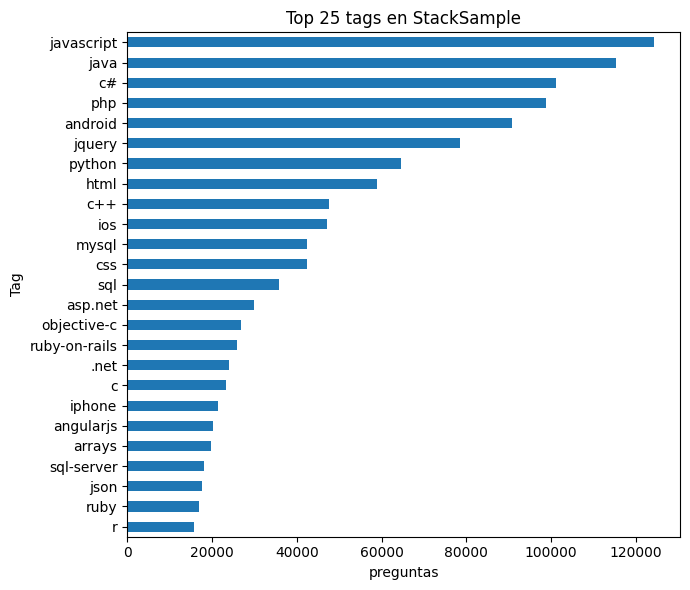

In [ ]:
top_tags = tags["Tag"].value_counts().head(25)
print(top_tags.to_string())

top_tags.iloc[::-1].plot(kind="barh", figsize=(7, 6))
plt.title("Top 25 tags en StackSample"); plt.xlabel("preguntas")
plt.tight_layout(); plt.show()


### Distribución de longitudes

count    1264216.0
mean        1410.0
std         1870.0
min           18.0
25%          514.0
50%          895.0
75%         1600.0
max        46489.0


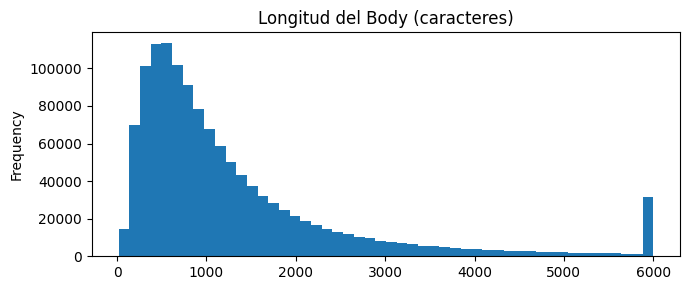

In [ ]:
body_len = questions["Body"].fillna("").str.len()
print(body_len.describe().round(0).to_string())

body_len.clip(upper=6000).plot(kind="hist", bins=50, figsize=(7, 3))
plt.title("Longitud del Body (caracteres)"); plt.tight_layout(); plt.show()


## Parte B — ETL de StackSample

### 5. Mapeo tag → categoría

Cada tag se asigna a una de las 8 categorías. StackSample es de ~2016, así que tecnologías
modernas (`fastapi`, `svelte`, `quarkus`...) no aparecen ahí — se incluyen porque sí rinden
con Dev.to (Parte C), que reutiliza este mismo mapeo.

In [ ]:
CATEGORY_TAGS = {
    "Backend": {
        "java", "spring", "spring-boot", "spring-mvc", "node.js", "express", "php", "laravel",
        "symfony", "ruby-on-rails", "ruby", "django", "flask", "asp.net", "asp.net-mvc",
        "asp.net-core", ".net", "c#", "rest", "api", "graphql", "microservices", "maven",
        "hibernate", "jpa", "servlets", "tomcat", "web-services", "soap", "gradle", "jsp",
        "fastapi", "nestjs", "go", "golang", "gin", "echo", "rust", "actix", "axum", "quarkus",
        "micronaut", "vertx", "ktor", "deno", "bun", "grpc", "serverless",
    },
    "Frontend": {
        "javascript", "typescript", "html", "html5", "css", "css3", "reactjs", "react",
        "angular", "angularjs", "vue.js", "vuejs", "jquery", "dom", "sass", "scss", "less",
        "webpack", "redux", "twitter-bootstrap", "bootstrap", "ajax", "ecmascript-6",
        "canvas", "svg", "responsive-design", "frontend", "web-development",
        "svelte", "sveltekit", "vite", "tailwindcss", "astro", "solidjs", "nuxt", "nuxt.js",
        "next.js", "nextjs", "remix", "vitest", "storybook", "webcomponents",
    },
    "Móvil": {
        "android", "android-studio", "android-layout", "android-fragments", "ios", "iphone",
        "swift", "swiftui", "kotlin", "react-native", "flutter", "dart", "xamarin",
        "objective-c", "cordova", "ionic-framework", "phonegap", "mobile", "android-intent",
        "uikit", "gradle-android", "jetpack-compose", "expo", "capacitor",
    },
    "Datos e IA": {
        "machine-learning", "deep-learning", "tensorflow", "keras", "pytorch", "pandas",
        "numpy", "scipy", "scikit-learn", "data-science", "nlp", "artificial-intelligence",
        "computer-vision", "opencv", "matplotlib", "jupyter-notebook", "dataframe", "r",
        "statistics", "data-analysis", "neural-network", "classification", "regression",
        "llm", "openai", "chatgpt", "langchain", "huggingface", "transformers", "generative-ai",
        "mlops", "data-engineering", "spark", "apache-spark", "airflow",
    },
    "DevOps y Cloud": {
        "docker", "kubernetes", "amazon-web-services", "aws", "azure", "google-cloud-platform",
        "devops", "jenkins", "terraform", "ansible", "nginx", "apache", "linux", "bash", "shell",
        "ubuntu", "deployment", "git", "github", "heroku", "ci", "continuous-integration",
        "virtual-machine", "networking", "server",
        "github-actions", "gitlab-ci", "helm", "prometheus", "grafana", "observability",
        "cloudflare", "vercel", "netlify", "oci", "oracle-cloud",
    },
    "Bases de datos": {
        "sql", "mysql", "postgresql", "postgres", "mongodb", "oracle", "sql-server", "tsql",
        "plsql", "database", "sqlite", "redis", "elasticsearch", "nosql", "database-design",
        "jdbc", "entity-framework", "join", "query-optimization", "indexing", "transactions",
        "stored-procedures", "cassandra", "dynamodb", "orm", "sequelize", "prisma", "supabase",
    },
    "Seguridad": {
        "security", "authentication", "authorization", "encryption", "oauth", "oauth-2.0",
        "jwt", "ssl", "https", "cryptography", "hash", "xss", "sql-injection", "cors",
        "spring-security", "csrf", "passwords", "openssl", "certificate", "penetration-testing",
        "vulnerability", "owasp", "keycloak", "auth0", "zero-trust",
    },
    "Fundamentos": {
        "algorithm", "data-structures", "recursion", "big-o", "sorting", "arrays", "string",
        "pointers", "oop", "design-patterns", "time-complexity", "math", "dynamic-programming",
        "linked-list", "binary-tree", "graph", "hashmap", "complexity", "memory-management",
        "testing", "unit-testing", "tdd", "clean-code", "refactoring", "solid-principles",
        "career", "beginners", "learning", "programming",
    },
}

TAG_TO_CATEGORY = {tag: cat for cat, tag_set in CATEGORY_TAGS.items() for tag in tag_set}

print(f"tags mapeados: {len(TAG_TO_CATEGORY)}")
for cat in CATEGORIES:
    print(f"  {cat:<16} {len(CATEGORY_TAGS[cat])} tags")


tags mapeados: 267
  Backend          48 tags
  Frontend         42 tags
  Móvil            24 tags
  Datos e IA       35 tags
  DevOps y Cloud   36 tags
  Bases de datos   28 tags
  Seguridad        25 tags
  Fundamentos      29 tags


### 3. Category Mapping
Normaliza tags y asigna cada registro a una de las ocho categorías.

In [ ]:
def normalize_tag(tag: str) -> str:
    """'Spring-Boot' -> 'springboot'. Conserva acentos y ñ (tags en español)."""
    return re.sub(r"[^a-z0-9áéíóúüñ]", "", tag.lower())

# Tags de Dev.to que se escriben distinto, no solo sin puntuación.
# Los genéricos (webdev, beginners...) van aparte en GENERIC_TAGS, con voto reducido.
DEVTO_ALIASES = {
    "Backend": {"node", "nodejs", "backend", "springboot", "dotnet", "csharp",
                "restapi", "webapi", "expressjs", "aspnet"},
    "Frontend": {"vue", "frontenddevelopment", "tailwind", "css3"},
    "Móvil": {"reactnative", "androiddev", "iosdev", "mobiledev", "mobileapp"},
    "Datos e IA": {"ai", "machinelearning", "datascience", "deeplearning",
                   "dataengineering", "genai", "rag", "llms", "dataanalysis"},
    "DevOps y Cloud": {"cloudcomputing", "cicd", "cloudnative", "sre", "platformengineering"},
    "Bases de datos": {"databases", "sqlserver", "mongo", "vectordatabase"},
    "Seguridad": {"cybersecurity", "infosec", "appsec", "websecurity", "pentesting",
                  "ethicalhacking"},
    "Fundamentos": {"algorithms", "datastructures", "computerscience", "dsa", "cleancode",
                     "designpatterns", "bigo", "leetcode", "codingchallenge", "solid",
                     "unittesting"},
}

# Tags en español de es.stackoverflow.
SPANISH_TAG_ALIASES = {
    "Backend": {"servidor", "peticiones", "peticion", "api-rest", "servicios-web"},
    "Frontend": {"formularios", "formulario", "diseño-web", "interfaz", "navegador",
                 "estilos", "maquetacion"},
    "Móvil": {"movil", "móvil", "aplicacion-movil", "aplicaciones-moviles"},
    "Datos e IA": {"aprendizaje-automatico", "inteligencia-artificial", "estadistica",
                   "ciencia-de-datos"},
    "DevOps y Cloud": {"despliegue", "servidores", "nube", "contenedores"},
    "Bases de datos": {"base-de-datos", "bases-de-datos", "consultas", "consulta",
                        "tablas", "registros"},
    "Seguridad": {"seguridad", "cifrado", "contraseñas", "contrasenas", "autenticacion",
                  "autenticación", "permisos", "vulnerabilidades",
                  "certificado", "certificado-ssl", "certificados", "firewall",
                  "iptables", "encriptacion", "encriptación", "criptografia",
                  "criptografía", "firma-digital", "hashing", "autorizacion",
                  "autorización", "vulnerabilidad", "inyeccion-sql", "captcha",
                  "seguridad-web", "antivirus"},
    "Fundamentos": {"poo", "funciones", "funcion", "lista", "listas", "arreglos", "arreglo",
                     "algoritmo", "algoritmos", "recursividad", "herencia", "ordenamiento",
                     "estructuras-de-datos", "cadenas", "bucles", "clases", "objetos",
                     "programacion-orientada-a-objetos"},
}

# Tags originales + variantes normalizadas. Sin filtro de longitud (conserva 'ai', 'go').
TAG_TO_CATEGORY = {}
collisions = []
for category, tag_set in CATEGORY_TAGS.items():
    originals = (tag_set | DEVTO_ALIASES.get(category, set())
                 | SPANISH_TAG_ALIASES.get(category, set()))
    derived = {normalize_tag(t) for t in originals} - {t.lower() for t in originals}
    for key in {t.lower() for t in originals} | {d for d in derived if len(d) >= 3}:
        previous = TAG_TO_CATEGORY.get(key)
        if previous is not None and previous != category:
            collisions.append((key, previous, category))  # ambigüedad: se descarta
            continue
        TAG_TO_CATEGORY[key] = category

for key, _, _ in collisions:
    TAG_TO_CATEGORY.pop(key, None)

print(f"claves de tag mapeadas: {len(TAG_TO_CATEGORY)} "
      f"(antes de normalizar: {sum(len(s) for s in CATEGORY_TAGS.values())})")
if collisions:
    print(f"descartadas por ambigüedad ({len(collisions)}):")
    for key, a, b in collisions:
        print(f"  {key:<20} {a} / {b}")


claves de tag mapeadas: 458 (antes de normalizar: 267)


### 4. Text Cleaning and Filtering

In [ ]:
# Describen tono/público, no tema técnico. Con voto simple secuestrarían la categoría
# (["java","beginners","programming"] -> Fundamentos en vez de Backend). Pesan menos.
GENERIC_TAGS = {"beginners", "programming", "learning", "career", "tutorial",
                 "webdev", "codenewbie", "discuss", "news", "testing"}
GENERIC_WEIGHT = 0.3

# Transversales: técnicos, pero no deben decidir frente a un tag de dominio.
CROSSCUTTING_TAGS = {
    "security", "authentication", "authorization", "oauth", "oauth-2.0", "jwt",
    "ssl", "https", "cors", "encryption", "hash", "passwords", "certificate",
    "api", "rest",
    "java", "javascript", "typescript", "php", "ruby", "go", "golang", "rust", "c#",
}
CROSSCUTTING_WEIGHT = 0.3

# Descalifican anuncios de academia / ofertas de empleo.
NOISE_TAGS = {"training", "course", "courses", "institute", "coaching", "onlinetraining",
              "hiring", "jobs", "job", "internship", "recruitment", "placement",
              "in", "at", "of", "the", "for", "and", "to", "on", "full"}

def assign_category(tag_list):
    """Devuelve (categoría, confianza). (None, 0.0) si no hay señal fiable."""
    if any(t.lower() in NOISE_TAGS for t in tag_list):
        return None, 0.0

    votes, technical = Counter(), 0
    for raw_tag in tag_list:
        # Tag tal cual y normalizado (StackSample: 'spring-boot', Dev.to: 'springboot').
        tag = raw_tag.lower()
        if tag not in TAG_TO_CATEGORY:
            tag = normalize_tag(raw_tag)
        if tag not in TAG_TO_CATEGORY:
            continue

        if tag in GENERIC_TAGS:
            weight, is_technical = GENERIC_WEIGHT, 0
        elif tag in CROSSCUTTING_TAGS:
            weight, is_technical = CROSSCUTTING_WEIGHT, 1
        else:
            weight, is_technical = 1.0, 1

        votes[TAG_TO_CATEGORY[tag]] += weight
        technical += is_technical

    if not votes or technical < MIN_TECHNICAL_TAGS:
        return None, 0.0
    category, top = votes.most_common(1)[0]
    return category, top / sum(votes.values())


In [ ]:
tags_by_question = tags.groupby("Id")["Tag"].apply(list)
assigned = tags_by_question.apply(assign_category)

questions["category"] = questions["Id"].map(assigned.str[0])
questions["confidence"] = questions["Id"].map(assigned.str[1]).fillna(0.0)

before = len(questions)
questions = questions[questions["category"].notna()
                       & (questions["confidence"] >= MIN_CONFIDENCE)].copy()

print(f"con categoría fiable: {len(questions)} de {before}")
print(questions["category"].value_counts().to_string())


con categoría fiable: 402627 de 1264216
category
Frontend          121731
Backend            93493
Móvil              70166
Bases de datos     62204
Fundamentos        29196
DevOps y Cloud     17117
Datos e IA          6032
Seguridad           2688


Aplica el mapeo de tags a categorías y filtra documentos ambiguos.

In [ ]:
questions["title"] = questions["Title"].map(clean_text)
questions["body"] = questions["Body"].map(clean_text)

print("Ejemplo limpio:\n", questions["body"].iloc[0][:300])


Ejemplo limpio:
 Has anyone got experience creating SQL-based ASP.NET site-map providers? I've got the default XML file web.sitemap working properly with my Menu and SiteMapPath controls, but I'll need a way for the users of my site to create and modify pages dynamically. I need to tie page viewing permissions into 


### 8. Filtrado por calidad y longitud

In [ ]:
before = len(questions)
questions = questions[questions["Score"] >= SCORE_MIN]
questions = questions[questions["body"].str.len() >= MIN_CHARS]
questions["body"] = questions["body"].str[:MAX_CHARS]
questions = questions.drop_duplicates(subset="title")
print(f"filtrado: {before} -> {len(questions)}")

stack_df = pd.DataFrame({
    "id": "so-" + questions["Id"].astype(int).astype(str),
    "title": questions["title"],
    "body": questions["body"],
    "category": questions["category"],
    "source": "stackoverflow",
    "url": "https://stackoverflow.com/questions/" + questions["Id"].astype(int).astype(str),
    "language": "en",
    "quality": questions["Score"],
})
print("StackSample listo:", len(stack_df), "documentos")


filtrado: 402627 -> 179997
StackSample listo: 179997 documentos


### Test — contaminación residual en el texto limpio
Mide si vale la pena ampliar `clean_text()` (URLs, bloques de código, comillas tipográficas).

In [ ]:
CODE_LEAK_PATTERNS = {
    "bloque_codigo_backticks": re.compile(r"```"),
    "url": re.compile(r"https?://\S+"),
    "ruta_paquete_estilo_java": re.compile(r"\b[a-zA-Z0-9_]+\.[a-zA-Z0-9_]+\.[a-zA-Z0-9_]+\b"),
    "comillas_tipograficas": re.compile(r"[\u2018\u2019\u201C\u201D]"),
}

sample = questions.sample(n=500, random_state=SEED)
sample_bodies = sample["body"]

print(f"{'patrón':<30}{'docs afectados':>16}{'% de la muestra':>18}")
print("-" * 64)
for name, pattern in CODE_LEAK_PATTERNS.items():
    hits = sample_bodies.str.contains(pattern, regex=True, na=False).sum()
    print(f"{name:<30}{hits:>16}{100*hits/len(sample):>17.1f}%")

worst = sample_bodies[sample_bodies.str.contains(
    CODE_LEAK_PATTERNS["ruta_paquete_estilo_java"], regex=True, na=False)]
if len(worst):
    print("\nEjemplo con ruido residual:\n", worst.iloc[0][:400])


patrón                          docs afectados   % de la muestra
----------------------------------------------------------------
bloque_codigo_backticks                      0              0.0%
url                                         77             15.4%
ruta_paquete_estilo_java                   149             29.8%
comillas_tipograficas                        0              0.0%

Ejemplo con ruido residual:
 I've recently downloaded STS and I tried firing up the TC Server, but it gives this error: Server Pivotal tc Server Developer Edition v3.1 failed to start. Error: Could not find or load main class Files.Spring.sts-bundle.pivotal-tc-server-developer-3.1.0.RELEASE.base-instance.conf.logging.properties Java HotSpot(TM) 64-Bit Server VM warning: ignoring option MaxPermSize=256m; support was removed in


### Test — clean_text_v2 vs. clean_text actual
Compara el impacto de limpiar URLs/código/comillas sobre el vocabulario TF-IDF.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

QUOTE_MAP = str.maketrans({"\u2018": "'", "\u2019": "'", "\u201C": '"', "\u201D": '"'})

def clean_text_v2(text):
    if pd.isna(text):
        return ""
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = EMOJI_PATTERN.sub("", text)
    text = re.sub(r"```.*?```", " ", text, flags=re.DOTALL)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"`[^`]+`", " ", text)
    text = text.translate(QUOTE_MAP)
    text = re.sub(r"\s+", " ", text).strip()
    return text

sample = questions.sample(n=500, random_state=SEED)
before = sample["Body"].map(clean_text)
after = sample["Body"].map(clean_text_v2)

print(f"reducción de caracteres promedio: {1 - after.str.len().sum()/before.str.len().sum():.1%}")

_local_tfidf_params = dict(ngram_range=(1, 2), min_df=3, max_features=20_000)
vec_before = TfidfVectorizer(**_local_tfidf_params).fit(before)
vec_after = TfidfVectorizer(**_local_tfidf_params).fit(after)

def count_noise_terms(vectorizer):
    terms = vectorizer.get_feature_names_out()
    noise = [t for t in terms if re.search(r"https?|www\.|\.com|\.org", t)]
    return len(noise), len(terms)

nb, tb = count_noise_terms(vec_before)
na, ta = count_noise_terms(vec_after)
print(f"términos de ruido en vocabulario ANTES:    {nb} de {tb}")
print(f"términos de ruido en vocabulario DESPUÉS:  {na} de {ta}")


reducción de caracteres promedio: 1.1%
términos de ruido en vocabulario ANTES:    15 de 4770
términos de ruido en vocabulario DESPUÉS:  6 de 4733


## Parte C — Dev.to (segunda fuente)

### 9. Descargar artículos

La API pública devuelve hasta 1000 artículos por request. El listado trae `description`
(~150-250 caracteres), no el artículo completo — suficiente para clasificar sin pagar
el costo de una request por artículo.

In [ ]:
DEVTO_API = "https://dev.to/api/articles"

def fetch_devto(tag: str, pages: int = DEVTO_PAGES, per_page: int = DEVTO_PER_PAGE) -> list:
    """Descarga artículos de Dev.to por tag."""
    collected = []
    for page in range(1, pages + 1):
        try:
            response = requests.get(
                DEVTO_API,
                params={"tag": tag, "per_page": per_page, "page": page},
                timeout=30,
            )
        except requests.RequestException as exc:
            print(f"  ! {tag}: error de red ({exc})")
            break
        if response.status_code != 200:
            print(f"  ! {tag}: HTTP {response.status_code}")
            break
        batch = response.json()
        if not batch:
            break
        collected.extend(batch)
        time.sleep(DEVTO_SLEEP)
    return collected

probe = fetch_devto("python", pages=1, per_page=5)
print(f"conexión OK — {len(probe)} artículos de muestra")
if probe:
    print("campos disponibles:", sorted(probe[0].keys())[:12], "...")


conexión OK — 5 artículos de muestra
campos disponibles: ['canonical_url', 'collection_id', 'comments_count', 'cover_image', 'created_at', 'crossposted_at', 'description', 'edited_at', 'id', 'language', 'last_comment_at', 'path'] ...


### 10. Recolectar artículos en inglés
Cada artículo pasa por el mismo `assign_category` que StackSample.

In [ ]:
DEVTO_TAGS = [
    "javascript", "react", "node", "python", "java", "go", "rust",
    "backend", "springboot", "csharp", "dotnet", "php", "laravel", "api",
    "css", "typescript", "vue", "angular", "webdev",
    "android", "flutter", "kotlin", "swift", "reactnative",
    "machinelearning", "datascience", "ai", "llm",
    "docker", "kubernetes", "aws", "devops", "cloud",
    "sql", "database", "postgres", "mongodb",
    # 'security' es transversal (ver CROSSCUTTING_TAGS); estos tags son de dominio.
    "security", "cybersecurity", "infosec", "appsec", "pentesting", "ethicalhacking",
    "algorithms", "datastructures", "computerscience", "dsa",
    "beginners", "programming", "testing", "career",
]

raw_articles, seen_ids = [], set()
for tag in DEVTO_TAGS:
    batch = fetch_devto(tag)
    fresh = [a for a in batch if a["id"] not in seen_ids]
    seen_ids.update(a["id"] for a in fresh)
    raw_articles.extend(fresh)
    print(f"  {tag:<16} +{len(fresh):>4} (total {len(raw_articles)})")

print(f"\nartículos únicos descargados: {len(raw_articles)}")


  javascript       +2000 (total 2000)
  react            +1831 (total 3831)
  node             +1701 (total 5532)
  python           +1927 (total 7459)
  java             +1961 (total 9420)
  go               +1975 (total 11395)
  rust             +1952 (total 13347)
  backend          +1491 (total 14838)
  springboot       +1728 (total 16566)
  csharp           +1985 (total 18551)
  dotnet           + 970 (total 19521)
  php              +1870 (total 21391)
  laravel          +1339 (total 22730)
  api              +1473 (total 24203)
  css              +1898 (total 26101)
  typescript       +1414 (total 27515)
  vue              +1900 (total 29415)
  angular          +1765 (total 31180)
  webdev           +1146 (total 32326)
  android          +1901 (total 34227)
  flutter          +1854 (total 36081)
  kotlin           +1698 (total 37779)
  swift            +1962 (total 39741)
  reactnative      +1755 (total 41496)
  machinelearning  +1745 (total 43241)
  datascience      +1660 (tota

### 11. Recolectar contenido en español
Centenares, no miles — alcanza para evaluar en español, no para entrenar solo en español.

In [ ]:
SPANISH_TAGS = ["espanol", "spanish", "latam", "desarrolloweb",
                "ciberseguridad", "inteligenciaartificial"]
SPANISH_PAGES = 5

raw_spanish = []
for tag in SPANISH_TAGS:
    batch = fetch_devto(tag, pages=SPANISH_PAGES)
    fresh = [a for a in batch if a["id"] not in seen_ids]
    seen_ids.update(a["id"] for a in fresh)
    raw_spanish.extend(fresh)
    print(f"  {tag:<16} +{len(fresh)}")

print(f"\ncandidatos en español: {len(raw_spanish)}")


  espanol          +558
  spanish          +1701
  latam            +95
  desarrolloweb    +24
  ciberseguridad   +17
  inteligenciaartificial +75

candidatos en español: 2470


### 12. Detectar el idioma

El tag no garantiza el idioma real. `py3langid` decide, y la proporción de palabras función
españolas confirma — cada condición cubre lo que a la otra se le escapa (portugués comparte
stopwords con español; títulos técnicos cortos en inglés engañan al detector solo).

In [ ]:
SPANISH_STOPWORDS = {
    "de", "la", "que", "el", "en", "y", "los", "del", "las", "por", "con", "para", "una", "es", "al",
    "como", "más", "pero", "sus", "le", "ya", "o", "este", "sí", "porque", "esta", "son", "entre",
    "cuando", "muy", "sin", "sobre", "también", "me", "hasta", "hay", "donde", "quien", "desde",
    "todo", "nos", "durante", "todos", "uno", "les", "ni", "contra", "otros", "ese", "eso", "ante",
    "ellos", "esto", "antes", "algunos", "qué", "unos", "yo", "otro", "otra", "él", "tanto", "esa",
    "estos", "mucho", "nada", "muchos", "cual", "poco", "ella", "estar", "estas", "algunas", "algo",
    "nosotros", "vamos", "hacer", "puede", "tiene", "ser", "así", "cada", "forma", "parte",
}

# Restringido a los idiomas del corpus: sin esto el detector reparte el español
# entre sus vecinos romances.
LANGUAGE_CANDIDATES = ["es", "en", "pt", "fr", "de", "it", "nl", "tr", "ja", "zh", "ru", "id"]
langid.set_languages(LANGUAGE_CANDIDATES)

def looks_spanish(text: str, threshold: float = 0.10) -> bool:
    words = re.findall(r"[a-záéíóúñü]+", text.lower())
    if len(words) < 10:
        return False
    if langid.classify(text)[0] != "es":
        return False
    return sum(1 for w in words if w in SPANISH_STOPWORDS) / len(words) >= threshold

# Un caso por forma de fallar: español, inglés, título técnico en inglés, portugués, francés.
for text, expected in (
    ("En este artículo vamos a ver cómo se construye una API REST con Java y Spring Boot", True),
    ("Cómo crear agentes con estado en Durable Objects usando el SDK de Cloudflare", True),
    ("In this article we are going to build a REST API using Java and Spring Boot today", False),
    ("I built my AI an operating system with MySQL, PHP and Bash and it works fine", False),
    ("Neste artigo você vai aprender como criar uma API REST com Java, mas não é tão simples", False),
    ("Pourquoi tes routes Express deviennent illisibles et le seul geste qui les sauve", False),
):
    result = looks_spanish(text)
    print(f"  [{'ok' if result == expected else 'REVISAR'}] {str(result):<6} {text[:58]}...")


  [ok] True   En este artículo vamos a ver cómo se construye una API RES...
  [ok] True   Cómo crear agentes con estado en Durable Objects usando el...
  [ok] False  In this article we are going to build a REST API using Jav...
  [ok] False  I built my AI an operating system with MySQL, PHP and Bash...
  [ok] False  Neste artigo você vai aprender como criar uma API REST com...
  [ok] False  Pourquoi tes routes Express deviennent illisibles et le se...


### 13. Convertir los artículos al esquema del corpus

Mismo esquema que StackSample. El set en español combina los tags de idioma (paso 11)
con el español que aparece entre los tags técnicos (paso 10).

Los documentos en español no entran al corpus de entrenamiento (que se queda con
`devto_en` + StackSample) — evaluar en español mide transferencia cross-lingual real.

In [ ]:
CORPUS_COLUMNS = ["id", "title", "body", "category", "source", "url", "language", "quality"]

def articles_to_frame(articles: list, force_language: str | None = None) -> pd.DataFrame:
    rows = []
    for article in articles:
        title = clean_text(article.get("title", ""))
        description = clean_text(article.get("description", "") or "")
        full_text = f"{title}. {description}"
        if len(full_text) < MIN_CHARS:
            continue

        max_desc_len = max(0, MAX_CHARS - len(title) - 2)
        description = description[:max_desc_len]

        category, confidence = assign_category([t.lower() for t in article.get("tag_list", [])])
        if category is None or confidence < MIN_CONFIDENCE:
            continue

        language = force_language or ("es" if looks_spanish(full_text) else "en")
        rows.append({
            "id": f"devto-{article['id']}",
            "title": title,
            "body": description,
            "category": category,
            "source": "devto",
            "url": article.get("url"),
            "language": language,
            "quality": article.get("public_reactions_count", 0) or 0,
        })
    return pd.DataFrame(rows, columns=CORPUS_COLUMNS)


## Parte D — Stack Exchange (español y categorías flojas)

Dos huecos medidos en el diagnóstico del notebook de entrenamiento (sección 8b):
StackOverflow(en) vs. Dev.to(en) por formato de texto, y Dev.to(en) vs. Dev.to(es) por idioma.
Nada atacaba el segundo, porque se entrenaba con cero español.

Seguridad además es escasa en todas las fuentes. La red de Stack Exchange resuelve los dos:
en los sitios temáticos, el sitio ya es la etiqueta — sin votación de tags ni transversales.
Entran con cuota baja (`SOURCE_QUOTAS`): son Q&A, no artículos, y no deben desplazar a Dev.to.

### 14. Descarga y parseo de los volcados

In [ ]:
import py7zr
import xml.etree.ElementTree as ET

USE_STACKEXCHANGE = True  # False para saltar esta parte (~1.5 GB de descarga)

SE_DIR = pathlib.Path("stackexchange")
SE_DIR.mkdir(exist_ok=True)

# 'category' fija = el sitio es la etiqueta. None = se decide por tags.
# score_min=0 en es.stackoverflow: con umbral 1 se pierde 58% del volcado y Seguridad
# queda en 85 documentos. max_per_category es holgado para que el muestreo tenga margen.
SE_SITES = [
    {"site": "es.stackoverflow.com",
     "source": "es-stackoverflow", "language": "es", "category": None,
     "max_per_category": 3000, "score_min": 0},
    {"site": "security.stackexchange.com",
     "source": "security-se", "language": "en", "category": "Seguridad",
     "max_per_category": 3000, "score_min": 1},
    {"site": "dba.stackexchange.com",
     "source": "dba-se", "language": "en", "category": "Bases de datos",
     "max_per_category": 3000, "score_min": 1},
    {"site": "softwareengineering.stackexchange.com",
     "source": "softwareeng-se", "language": "en", "category": "Fundamentos",
     "max_per_category": 3000, "score_min": 1},
]

ARCHIVE_BASE = "https://archive.org/download/stackexchange/"

def download(url: str, target: pathlib.Path) -> pathlib.Path | None:
    if target.exists():
        print(f"  ya estaba: {target.name}")
        return target
    for attempt in range(3):
        try:
            with requests.get(url, stream=True, timeout=600) as r:
                r.raise_for_status()
                total, done = int(r.headers.get("content-length", 0)), 0
                with target.open("wb") as f:
                    for chunk in r.iter_content(1 << 20):
                        f.write(chunk)
                        done += len(chunk)
                        if total:
                            print(f"\r  {target.name}: {100 * done / total:5.1f} %", end="")
                print()
                return target
        except requests.RequestException as exc:
            print(f"\n  ! intento {attempt + 1}/3 falló para {target.name}: {exc}")
            if attempt == 2:
                print(f"  ! se omite {target.name} por error de descarga")
                return None
            time.sleep(2)
    return None


### 15. Del XML al esquema del corpus

`Posts.xml` se recorre con `iterparse` en streaming: la memoria se mantiene plana
en vez de crecer con el fichero (puede pesar varios GB).

In [ ]:
def _parse_tags(raw: str) -> list:
    """'<java><spring-boot>' o '|java|spring-boot|' -> ['java', 'spring-boot']."""
    if not raw:
        return []
    if "<" in raw:
        return re.findall(r"<([^>]+)>", raw)
    return [t for t in raw.split("|") if t]

def read_posts(xml_path: pathlib.Path, config: dict) -> pd.DataFrame:
    """Preguntas del volcado, ya en el esquema del corpus.

    Tope POR CATEGORÍA con muestreo de reservorio: el volcado está ordenado
    cronológicamente, y un tope global se queda con la mitad más antigua del sitio,
    hundiendo las categorías de tema reciente.
    """
    cap = config["max_per_category"]
    buckets, seen = {}, Counter()
    rng = np.random.default_rng(SEED)

    context = ET.iterparse(xml_path, events=("start", "end"))
    _, root = next(context)

    for event, elem in context:
        if event != "end" or elem.tag != "row":
            continue
        try:
            if elem.get("PostTypeId") != "1":  # 1 = pregunta, 2 = respuesta
                continue
            score = int(elem.get("Score", 0))
            if score < config.get("score_min", SCORE_MIN):
                continue

            title = clean_text(elem.get("Title", ""))
            body = clean_text(elem.get("Body", ""))
            if len(f"{title}. {body}") < MIN_CHARS:
                continue

            tags_ = [t.lower() for t in _parse_tags(elem.get("Tags", ""))]
            if config["category"] is not None:
                category = config["category"]  # sitio temático: el sitio manda
            else:
                category, confidence = assign_category(tags_)
                if category is None or confidence < MIN_CONFIDENCE:
                    continue

            row = {
                "id": f"{config['source']}-{elem.get('Id')}",
                "title": title,
                "body": body[:MAX_CHARS] if body else "",
                "category": category,
                "source": config["source"],
                "url": f"https://{config['site']}/questions/{elem.get('Id')}",
                "language": config["language"],
                "quality": score,
            }

            # Reservorio: hasta 'cap' por categoría, uniforme sobre el fichero.
            seen[category] += 1
            reservoir = buckets.setdefault(category, [])
            if len(reservoir) < cap:
                reservoir.append(row)
            else:
                j = int(rng.integers(seen[category]))
                if j < cap:
                    reservoir[j] = row
        finally:
            root.clear()  # memoria plana

    rows = [r for reservoir in buckets.values() for r in reservoir]
    return pd.DataFrame(rows, columns=CORPUS_COLUMNS)

def load_site(config: dict) -> pd.DataFrame:
    name = config["site"]
    print(f"\n{name} (score >= {config.get('score_min', SCORE_MIN)})")

    archive_path = download(ARCHIVE_BASE + name + ".7z", SE_DIR / f"{name}.7z")
    if archive_path is None:
        print("  -> sin datos para esta fuente")
        return pd.DataFrame(columns=CORPUS_COLUMNS)

    target = SE_DIR / config["source"]
    xml_path = target / "Posts.xml"
    if not xml_path.exists():
        print("  extrayendo Posts.xml...")
        try:
            with py7zr.SevenZipFile(archive_path, "r") as z:
                z.extract(path=target, targets=["Posts.xml"])
        except Exception as exc:
            print(f"  ! no se pudo extraer Posts.xml: {exc}")
            return pd.DataFrame(columns=CORPUS_COLUMNS)

    try:
        frame = read_posts(xml_path, config)
    except Exception as exc:
        print(f"  ! no se pudo procesar Posts.xml: {exc}")
        return pd.DataFrame(columns=CORPUS_COLUMNS)

    print(f"  -> {len(frame)} preguntas útiles")
    archive_path.unlink(missing_ok=True)  # Colab va justo de disco
    return frame


### 16. Ejecutar la ingesta

In [ ]:
failed_sites = []
if USE_STACKEXCHANGE:
    se_frames = []
    for cfg in SE_SITES:
        try:
            frame = load_site(cfg)
        except Exception as exc:
            print(f"  ! falla inesperada para {cfg['site']}: {exc}")
            failed_sites.append(cfg["site"])
            frame = pd.DataFrame(columns=CORPUS_COLUMNS)
        se_frames.append(frame)

    se_df = (pd.concat([f for f in se_frames if not f.empty], ignore_index=True)
             if se_frames else pd.DataFrame(columns=CORPUS_COLUMNS))
    se_df = dedupe_titles(se_df)
    print(f"Stack Exchange listo: {len(se_df)} registros")
else:
    se_df = pd.DataFrame(columns=CORPUS_COLUMNS)
    print("Se omitió Stack Exchange.")

# Test español Q&A: se reserva antes del entrenamiento, para que no entre a train.
ES_QA_TEST_PER_CATEGORY = 100
if len(se_df):
    candidates = se_df[se_df["source"] == "es-stackoverflow"]
    picked = [group.sample(n=min(len(group), ES_QA_TEST_PER_CATEGORY), random_state=SEED)
              for _, group in candidates.groupby("category")]
    test_es_qa = pd.concat(picked) if picked else se_df.head(0)
    se_df = se_df.drop(index=test_es_qa.index)
    test_es_qa = test_es_qa.reset_index(drop=True)
else:
    test_es_qa = pd.DataFrame(columns=CORPUS_COLUMNS)

print(f"\ntest español Q&A reservado: {len(test_es_qa)} documentos")
if len(test_es_qa):
    reparto = test_es_qa["category"].value_counts().reindex(CATEGORIES).fillna(0).astype(int)
    for category, n in reparto.items():
        aviso = f" <- solo hay {n}" if n < ES_QA_TEST_PER_CATEGORY else ""
        print(f"  {category:<20} {n:>4}{aviso}")

print("\n" + "=" * 54)
print("RESUMEN STACK EXCHANGE")
print("=" * 54)
print(f"registros cargados de SE:     {len(se_df) + len(test_es_qa)}")
print(f"registros para entrenamiento: {len(se_df)}")
print(f"registros reservados (test):  {len(test_es_qa)}")
print("fuentes procesadas:")
for cfg in SE_SITES:
    source_name = cfg["source"]
    if source_name in se_df["source"].tolist():
        n = int((se_df["source"] == source_name).sum())
        print(f"  - {source_name}: {n} registros en entrenamiento")
    else:
        print(f"  - {source_name}: sin datos cargados")
print("fuentes fallidas:", failed_sites or "ninguna")



es.stackoverflow.com (score >= 0)

  ! intento 1/3 falló para es.stackoverflow.com.7z: 500 Server Error: Internal Server Error for url: https://dn720201.ca.archive.org/0/items/stackexchange/es.stackoverflow.com.7z
  es.stackoverflow.com.7z: 100.0 %
  extrayendo Posts.xml...
  -> 18918 preguntas útiles

security.stackexchange.com (score >= 1)
  security.stackexchange.com.7z: 100.0 %
  extrayendo Posts.xml...
  -> 3000 preguntas útiles

dba.stackexchange.com (score >= 1)
  dba.stackexchange.com.7z: 100.0 %
  extrayendo Posts.xml...
  -> 3000 preguntas útiles

softwareengineering.stackexchange.com (score >= 1)
  softwareengineering.stackexchange.com.7z: 100.0 %
  extrayendo Posts.xml...
  -> 3000 preguntas útiles
Stack Exchange listo: 27918 registros

test español Q&A reservado: 800 documentos
  Backend               100
  Frontend              100
  Móvil                 100
  Datos e IA            100
  DevOps y Cloud        100
  Bases de datos        100
  Seguridad             100
 

## Parte E — Unificar, balancear y guardar

Une StackSample, Dev.to y Stack Exchange, elimina duplicados, balancea categorías y
fuentes, exporta los tres JSONL, valida el esquema final.

In [ ]:
stack_df = pd.DataFrame({
    "id": "so-" + questions["Id"].astype(int).astype(str),
    "title": questions["title"],
    "body": questions["body"],
    "category": questions["category"],
    "source": "stackoverflow",
    "url": "https://stackoverflow.com/questions/" + questions["Id"].astype(int).astype(str),
    "language": "en",
    "quality": questions["Score"],
})

# raw_articles trae tags técnicos en inglés (python, docker...), pero eso no garantiza
# que el texto lo esté. Se detecta con looks_spanish() en vez de forzar "en", para no
# perder el español que aparece mezclado ahí.
devto_from_technical_tags = articles_to_frame(raw_articles, force_language=None)
devto_en = devto_from_technical_tags[devto_from_technical_tags["language"] == "en"].reset_index(drop=True)
devto_es_from_technical = devto_from_technical_tags[devto_from_technical_tags["language"] == "es"].reset_index(drop=True)

print(f"raw_articles (tags técnicos): {len(devto_from_technical_tags)} total "
      f"-> {len(devto_en)} en / {len(devto_es_from_technical)} es")

devto_es_from_spanish_tags = articles_to_frame(raw_spanish, force_language="es")

# Ambas fuentes de español se combinan ANTES del split, para que el holdout
# salga de todo el pool disponible.
devto_es_all = pd.concat([devto_es_from_spanish_tags, devto_es_from_technical], ignore_index=True)
devto_es_all = dedupe_titles(devto_es_all)

if not devto_es_all.empty:
    devto_es_test = devto_es_all.sample(frac=0.25, random_state=SEED)
    devto_es_train = devto_es_all.drop(devto_es_test.index)
else:
    devto_es_test = pd.DataFrame(columns=CORPUS_COLUMNS)
    devto_es_train = pd.DataFrame(columns=CORPUS_COLUMNS)

print(f"devto_es total: {len(devto_es_all)} -> train {len(devto_es_train)} / test {len(devto_es_test)}")

corpus = pd.concat([stack_df, devto_en, devto_es_train, se_df], ignore_index=True)
corpus = dedupe_titles(corpus).reset_index(drop=True)

print(f"Registros antes de deduplicar: {len(stack_df) + len(devto_en) + len(devto_es_train) + len(se_df)}")
print(f"Registros después de deduplicar: {len(corpus)}")
print(corpus["source"].value_counts().to_string())
print(f"Test español: {len(devto_es_test)} Dev.to + {len(test_es_qa)} QA")


raw_articles (tags técnicos): 45004 total -> 44495 en / 509 es
devto_es total: 1009 -> train 757 / test 252
Registros antes de deduplicar: 252367
Registros después de deduplicar: 251884
source
stackoverflow       179997
devto                44771
es-stackoverflow     18118
security-se           3000
dba-se                3000
softwareeng-se        2998
Test español: 252 Dev.to + 800 QA


### 17b. Balanceo por categoría y por fuente

Tres criterios: tope por categoría (macro-F1 pesa las 8 igual), muestreo ponderado
por calidad (log1p, para que un artículo con 1000 reacciones no aplaste a los de 10),
y cuota por fuente — sin ella StackSample se lleva ~94% del corpus y el test español
queda 100% Dev.to, una asimetría de registro que el modelo paga en la métrica.

In [ ]:
# Techo por fuente dentro de cada categoría, no mínimo: si una fuente no alcanza,
# el hueco lo rellenan las demás.
SOURCE_QUOTAS = {
    "devto-es": 0.15,          # español real; escaso, se toma todo lo que haya
    "devto": 0.50,             # registro artículo en inglés — la referencia
    "es-stackoverflow": 0.20,  # español, pero registro Q&A
    "security-se": 0.15,
    "dba-se": 0.15,
    "softwareeng-se": 0.15,
}

def _weighted_sample(group: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    """n documentos, prefiriendo calidad, sin reemplazo (Efraimidis-Spirakis).

    DataFrame.sample(weights=...) revienta cuando n se acerca al tamaño del grupo;
    esto no tiene ese caso límite.
    """
    if n <= 0 or group.empty:
        return group.head(0)
    if n >= len(group):
        return group
    weights = (np.log1p(group["quality"].clip(lower=0)) + 0.1).to_numpy()
    u = np.random.default_rng(seed).random(len(group))
    keys = np.log(np.clip(u, 1e-12, 1.0)) / weights
    return group.iloc[np.argsort(keys)[::-1][:n]]

def balance(frame: pd.DataFrame, n_max: int, seed: int = SEED,
            quotas: dict | None = None) -> pd.DataFrame:
    """n_max documentos por categoría, respetando el techo de cada fuente."""
    quotas = SOURCE_QUOTAS if quotas is None else quotas
    parts = []
    for _, group in frame.groupby("category"):
        n = min(len(group), n_max)
        chosen, used, remaining = [], [], n

        for source_name, quota in quotas.items():
            if remaining <= 0:
                break
            available = group[group["source"] == source_name]
            k = min(len(available), int(round(n * quota)), remaining)
            selection = _weighted_sample(available, k, seed)
            chosen.append(selection)
            used.extend(selection.index)
            remaining -= len(selection)

        # El hueco lo cubren primero las fuentes sin cuota (StackSample).
        if remaining > 0:
            without_quota = group[~group["source"].isin(quotas)].drop(index=used, errors="ignore")
            selection = _weighted_sample(without_quota, remaining, seed)
            chosen.append(selection)
            used.extend(selection.index)
            remaining -= len(selection)

        # Si aún falta: relajar techos es preferible a dejar la categoría corta.
        if remaining > 0:
            chosen.append(_weighted_sample(group.drop(index=used, errors="ignore"), remaining, seed))

        parts.append(pd.concat(chosen) if chosen else group.head(0))

    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

before = corpus["source"].value_counts()
corpus = balance(corpus, N_MAX_PER_CATEGORY)
after = corpus["source"].value_counts()

print(f"total tras balancear: {len(corpus)}")
print(f"\n{'fuente':<20}{'candidatos':>12}{'en el corpus':>14}{'%':>7}")
for source_name in before.index:
    n = int(after.get(source_name, 0))
    print(f"{source_name:<20}{int(before[source_name]):>12}{n:>14}{100 * n / len(corpus):>6.1f}%")

es = (corpus["language"] == "es").mean()
print(f"\nregistro artículo (devto): {100 * after.get('devto', 0) / len(corpus):.1f} %")
print(f"español en el entrenamiento: {100 * es:.1f} %")


total tras balancear: 16000

fuente                candidatos  en el corpus      %
stackoverflow             179997          4073  25.5%
devto                      44771          8000  50.0%
es-stackoverflow           18118          3027  18.9%
security-se                 3000           300   1.9%
dba-se                      3000           300   1.9%
softwareeng-se              2998           300   1.9%

registro artículo (devto): 50.0 %
español en el entrenamiento: 20.0 %


### 18. Distribución final del corpus

source          dba-se  devto  es-stackoverflow  security-se  softwareeng-se  stackoverflow  TOTAL
category                                                                                          
Backend              0   1000               400            0               0            600   2000
Frontend             0   1000               400            0               0            600   2000
Móvil                0   1000               400            0               0            600   2000
Datos e IA           0   1000               400            0               0            600   2000
DevOps y Cloud       0   1000               400            0               0            600   2000
Bases de datos     300   1000               400            0               0            300   2000
Seguridad            0   1000               227          300               0            473   2000
Fundamentos          0   1000               400            0             300            300   2000

TOTAL cor

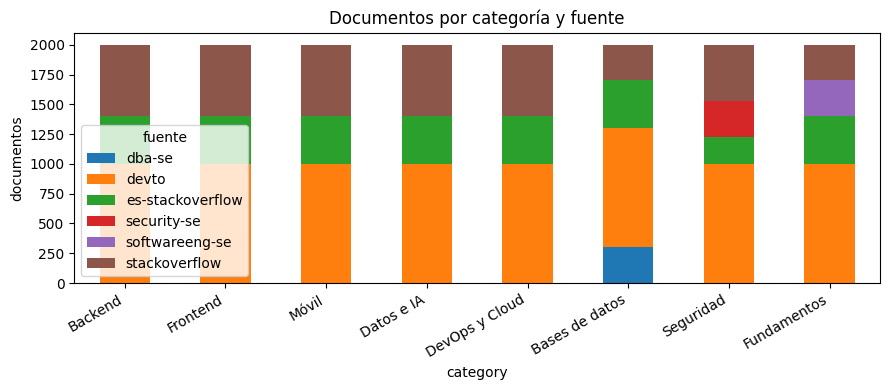

todas las categorías superan el mínimo de 400


In [ ]:
summary = (corpus.pivot_table(index="category", columns="source", values="id",
                               aggfunc="count", fill_value=0)
           .reindex(CATEGORIES).fillna(0).astype(int))
summary["TOTAL"] = summary.sum(axis=1)
print(summary.to_string())
print(f"\nTOTAL corpus: {len(corpus)} documentos")

summary.drop(columns="TOTAL").plot(kind="bar", stacked=True, figsize=(9, 4))
plt.title("Documentos por categoría y fuente"); plt.ylabel("documentos")
plt.xticks(rotation=30, ha="right"); plt.legend(title="fuente")
plt.tight_layout(); plt.show()

underfilled = summary[summary["TOTAL"] < N_MIN_PER_CATEGORY].index.tolist()
if underfilled:
    print(f"Por debajo de {N_MIN_PER_CATEGORY} documentos: {underfilled}")
    print("Soluciones: añade tags a CATEGORY_TAGS/DEVTO_TAGS, sube DEVTO_PAGES, o baja SCORE_MIN.")
else:
    print(f"todas las categorías superan el mínimo de {N_MIN_PER_CATEGORY}")

missing = [c for c in CATEGORIES if summary.loc[c, "TOTAL"] == 0]
assert not missing, f"Categorías sin datos: {missing}"


### 19. Split estratificado y guardado

In [ ]:
train, test = train_test_split(
    corpus.drop(columns="quality"),
    test_size=TEST_SIZE,
    stratify=corpus["category"],
    random_state=SEED,
)

test_es = pd.concat([devto_es_test, test_es_qa], ignore_index=True)
if "quality" in test_es.columns:
    test_es = test_es.drop(columns="quality")

def write_jsonl(frame: pd.DataFrame, path: pathlib.Path):
    saved_count = 0
    discarded_count = 0
    with path.open("w", encoding="utf-8") as f:
        for record in frame.to_dict("records"):
            record["title"] = clean_text(record["title"])
            record["body"] = clean_text(record["body"])
            if len(record["title"] + record["body"]) < 30:
                discarded_count += 1
                continue
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
            saved_count += 1
    print(f"{path.name}: {saved_count} documentos escritos · {discarded_count} descartados")
    return saved_count, discarded_count

print("Escribiendo archivos...")
train_summary = write_jsonl(train, OUT_DIR / "train_corpus.jsonl")
test_summary = write_jsonl(test, OUT_DIR / "test_corpus.jsonl")
test_es_summary = write_jsonl(test_es, OUT_DIR / "test_corpus_es.jsonl")

print("\n" + "=" * 54)
print("RESUMEN EXPORTACIÓN JSONL")
print("=" * 54)
print(f"train:   {len(train)} en split · {train_summary[0]} escritos · {train_summary[1]} descartados")
print(f"test:    {len(test)} en split · {test_summary[0]} escritos · {test_summary[1]} descartados")
print(f"test_es: {len(test_es)} en split · {test_es_summary[0]} escritos · {test_es_summary[1]} descartados")


Escribiendo archivos...
train_corpus.jsonl: 12800 documentos escritos · 0 descartados
test_corpus.jsonl: 3200 documentos escritos · 0 descartados
test_corpus_es.jsonl: 1052 documentos escritos · 0 descartados

RESUMEN EXPORTACIÓN JSONL
train:   12800 en split · 12800 escritos · 0 descartados
test:    3200 en split · 3200 escritos · 0 descartados
test_es: 1052 en split · 1052 escritos · 0 descartados


### 20. Validación del contrato

Verifica esquema, categorías válidas e IDs únicos antes de entregar el corpus al
notebook de entrenamiento.

In [ ]:
REQUIRED = {"id", "title", "body", "category", "source", "url", "language"}

for name in ("train_corpus.jsonl", "test_corpus.jsonl", "test_corpus_es.jsonl"):
    path = OUT_DIR / name
    rows = [json.loads(line) for line in path.open(encoding="utf-8") if line.strip()]
    if not rows:
        print(f"{name}: vacío")
        continue

    ids = set()
    for row in rows:
        assert REQUIRED <= row.keys(), f"{name}: faltan columnas en {row.get('id')}"
        assert row["category"] in CATEGORIES, f"{name}: categoría inesperada {row['category']}"
        assert row["language"] in {"es", "en"}, f"{name}: idioma inesperado {row['language']}"
        assert row["id"] not in ids, f"{name}: id duplicado {row['id']}"
        ids.add(row["id"])

    print(f"{name}: {len(rows)} registros válidos")


train_corpus.jsonl: 12800 registros válidos
test_corpus.jsonl: 3200 registros válidos
test_corpus_es.jsonl: 1052 registros válidos
